<a href="https://colab.research.google.com/github/muskanmathur2706-cloud/dataCleaningpd/blob/main/PolynomialRegression(MultipleFeatures)_Fish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
#from google.colab import files
#uploaded = files.upload()

Saving Fish.csv to Fish.csv


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('Fish.csv')

In [9]:
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [14]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
154,False
155,False
156,False
157,False


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


<Axes: xlabel='Length1', ylabel='Weight'>

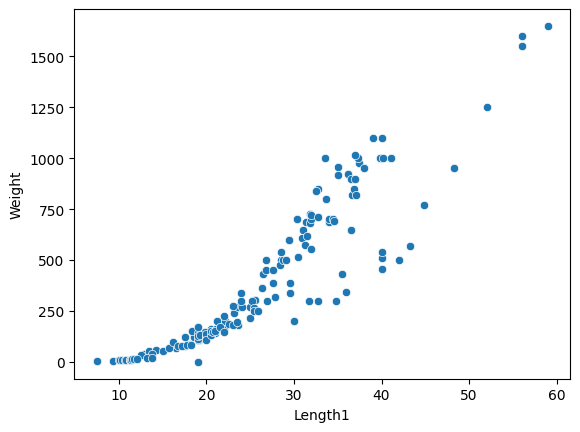

In [27]:
sns.scatterplot(data=df,x='Length1',y='Weight')


In [31]:
X=df.drop(['Weight','Species'],axis=1)
X.head()

,Length1,Length2,Length3,Height,Width
0,23.2,25.4,30.0,11.5200,4.0200
1,24.0,26.3,31.2,12.4800,4.3056
2,23.9,26.5,31.1,12.3778,4.6961
3,26.3,29.0,33.5,12.7300,4.4555
4,26.5,29.0,34.0,12.4440,5.1340


In [32]:
y=df['Weight']
y.head()

,Weight
0,242.0
1,290.0
2,340.0
3,363.0
4,430.0


In [33]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [34]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [35]:
y_pred=model.predict(X_test)

In [37]:
model.intercept_

np.float64(-515.305651338433)

In [38]:
model.coef_

array([ 43.5352649 ,   7.82179624, -25.25670105,  23.2289123 ,
        27.06649294])

In [42]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.8821430593048695

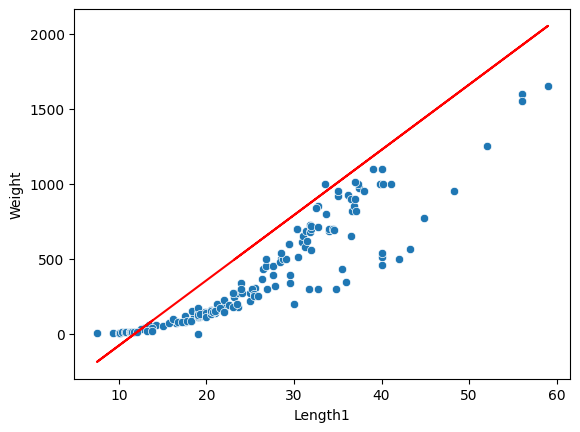

In [40]:
x_axis = df['Length1']
y_axis = 43.53 * x_axis - 515
sns.scatterplot(data=df,x='Length1',y='Weight')
plt.plot(x_axis,y_axis,color='red')
plt.show()

In [43]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

In [57]:
r2_list = []

for i in range(0,11):

   pf = PolynomialFeatures(degree=i)
   X_train_poly = pf.fit_transform(X_train)
   X_test_poly = pf.fit_transform(X_test)

   lr=LinearRegression()
   lr.fit(X_train_poly,y_train)
   y_pred=lr.predict(X_test_poly)

   r2s = r2_score(y_test,y_pred)

   r2_list.append(r2s)

In [58]:
print(r2_list)

[-0.023082268458468613, 0.8821430593048696, 0.9672675055786767, 0.9609431981617572, -422.86498116892227, -428.91736199843837, -1306.7900206333277, -3862.1649282700373, -7218.979550711392, -158961.2649634807, -202694.37925916773]


In [48]:
print(X_train_poly)

[[  1.          15.          16.2        ...  21.09013776  12.08535984
    6.92531856]
 [  1.          43.2         46.         ...  60.715264    37.94704
   23.7169    ]
 [  1.          23.9         26.5        ... 153.20993284  58.12738658
   22.05335521]
 ...
 [  1.          29.4         32.         ... 223.63407936  77.32621152
   26.73717264]
 [  1.          20.5         22.5        ...  46.131264    24.614208
   13.133376  ]
 [  1.          25.2         27.3        ...  69.272329    42.7577479
   26.39185129]]


In [49]:
X_train.head()

,Length1,Length2,Length3,Height,Width
75,15.0,16.2,17.2,4.5924,2.6316
138,43.2,46.0,48.7,7.7920,4.8700
2,23.9,26.5,31.1,12.3778,4.6961
86,20.0,22.0,23.5,6.1100,3.4075
45,20.5,22.5,25.3,7.0334,3.8203


In [50]:
lr=LinearRegression()
lr.fit(X_train_poly,y_train)

LinearRegression()

In [51]:
y_pred=lr.predict(X_test_poly)

In [53]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.9672675055786767